<a href="https://colab.research.google.com/github/DarkNacho/Machine-Learning/blob/main/S10-Neural-Networks/Laboratorio_Red_Neuronal_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio: Red Neuronal con MNIST  
**Curso:** Machine Learning  
**Total puntos:** 10

**Objetivo:** Implementar una red neuronal simple para clasificar dígitos escritos a mano del conjunto de datos MNIST utilizando Python y Keras.



## Paso 1: Cargar el conjunto de datos MNIST (1 punto)

Ejecuta el siguiente bloque para descargar y explorar el conjunto de datos.


In [ ]:
!pip install tensorflow

  Using cached tensorflow-2.19.0-cp311-cp311-win_amd64.whl (375.9 MB)
                                              0.0/135.6 kB ? eta -:--:--
     -------------------------------------  133.1/135.6 kB 2.6 MB/s eta 0:00:01
     -------------------------------------- 135.6/135.6 kB 2.0 MB/s eta 0:00:00
  Using cached astunparse-1.6.3-py2.py3-none-any.whl (12 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl (30 kB)
  Using cached gast-0.6.0-py3-none-any.whl (21 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl (26.4 MB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)
  Using cached protobuf-5.29.4-cp310-abi3-win_amd64.whl (434 kB)
  Using cached wrapt-1.17.2-cp311-cp311-win_amd64.whl (38 kB)
  Using cached grpcio-1.71.0-cp311-cp311-win_amd64.whl (4.3 MB)
  Using cached tensorboard-2.19.0-py3-none-any.whl (5.5 MB)
                                              0.0/1.4 MB ? eta -:--:--
     ----------


[notice] A new release of pip is available: 23.1.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from tensorflow.keras.datasets import mnist

# Cargar datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Tamaño del set de entrenamiento:", x_train.shape)
print("Tamaño del set de test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Tamaño del set de entrenamiento: (60000, 28, 28)
Tamaño del set de test: (10000, 28, 28)



## Paso 2: Visualizar ejemplos del dataset (1 punto)

✏️ **Slot para completar:** Visualiza al menos 5 imágenes con sus etiquetas utilizando `matplotlib.pyplot.imshow()`.


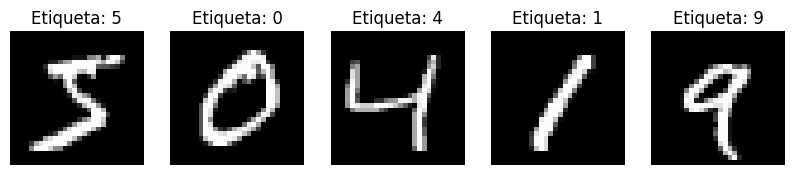

In [ ]:
import matplotlib.pyplot as plt

# Visualizar las primeras 5 imágenes del set de entrenamiento
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Etiqueta: {y_train[i]}")
    plt.axis("off")
plt.show()

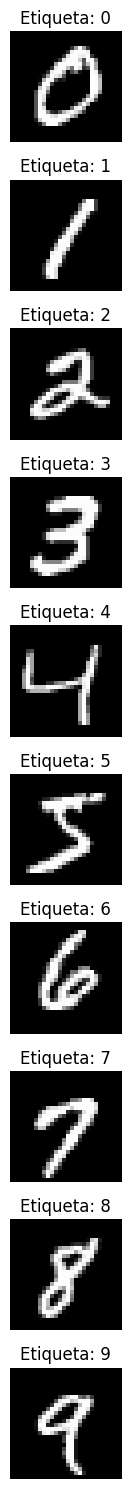

In [ ]:
# Encontrar el primer índice de cada dígito (0-9)
indices = [np.where(y_train == i)[0][0] for i in range(10)]

plt.figure(figsize=(3, 15))
for i, idx in enumerate(indices):
    plt.subplot(10, 1, i + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(f"Etiqueta: {y_train[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


## Paso 3: Preprocesamiento (1 punto)

✏️ **Slot para completar:**
- Normaliza las imágenes (divide por 255.0).
- Aplana cada imagen a un vector de 784 valores.
- Codifica las etiquetas con `to_categorical`.


In [ ]:
from tensorflow.keras.utils import to_categorical

# Normalizar imágenes
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# Aplanar imágenes (de 28x28 a 784)
x_train_flat = x_train_norm.reshape(-1, 28 * 28)
x_test_flat = x_test_norm.reshape(-1, 28 * 28)

# Codificar etiquetas en one-hot
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)


## Paso 4: Definir la red neuronal (2 puntos)

✏️ **Slot para completar:**
- Crea un modelo `Sequential`.
- Agrega una capa oculta con activación ReLU.
- Agrega una capa de salida con activación Softmax.
- Compila el modelo con `adam` y `categorical_crossentropy`.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Definir el modelo secuencial
model = Sequential()
# Capa oculta con 128 neuronas y activación ReLU
model.add(Dense(128, activation="relu", input_shape=(784,)))
# Capa de salida con 10 neuronas (una por clase) y activación softmax
model.add(Dense(10, activation="softmax"))

# Compilar el modelo
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

c:\Users\DarkNacho\Documents\Doctorado\2025\Machine Learning\Machine-Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



## Paso 5: Entrenar el modelo (1 punto)

✏️ **Slot para completar:** Entrena el modelo con `fit` durante 5 épocas y batch size 32.


In [ ]:
result = model.fit(
    x_train_flat, y_train_cat, epochs=5, batch_size=32, validation_split=0.1, verbose=1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8736 - loss: 0.4454 - val_accuracy: 0.9635 - val_loss: 0.1296
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9600 - loss: 0.1335 - val_accuracy: 0.9730 - val_loss: 0.0899
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0852 - val_accuracy: 0.9768 - val_loss: 0.0774
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9820 - loss: 0.0592 - val_accuracy: 0.9787 - val_loss: 0.0737
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9865 - loss: 0.0459 - val_accuracy: 0.9775 - val_loss: 0.0770



## Paso 6: Evaluar el modelo (1 punto)

✏️ **Slot para completar:** Evalúa el modelo con `evaluate()` en el conjunto de prueba.


In [ ]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test_cat, verbose=1)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Precisión en test: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9747 - loss: 0.0790
Pérdida en test: 0.0672
Precisión en test: 0.9790


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

Matriz de confusión:
[[ 971    0    1    1    1    0    2    2    2    0]
 [   0 1126    4    0    0    1    2    0    2    0]
 [   3    1 1011    0    1    0    2    8    6    0]
 [   0    0    9  99

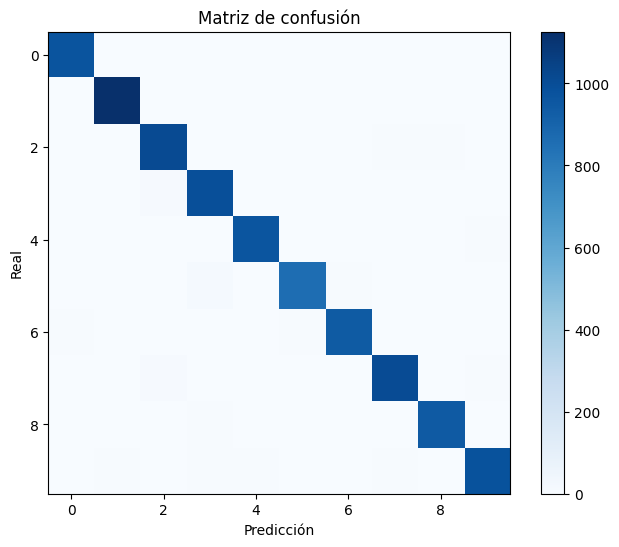

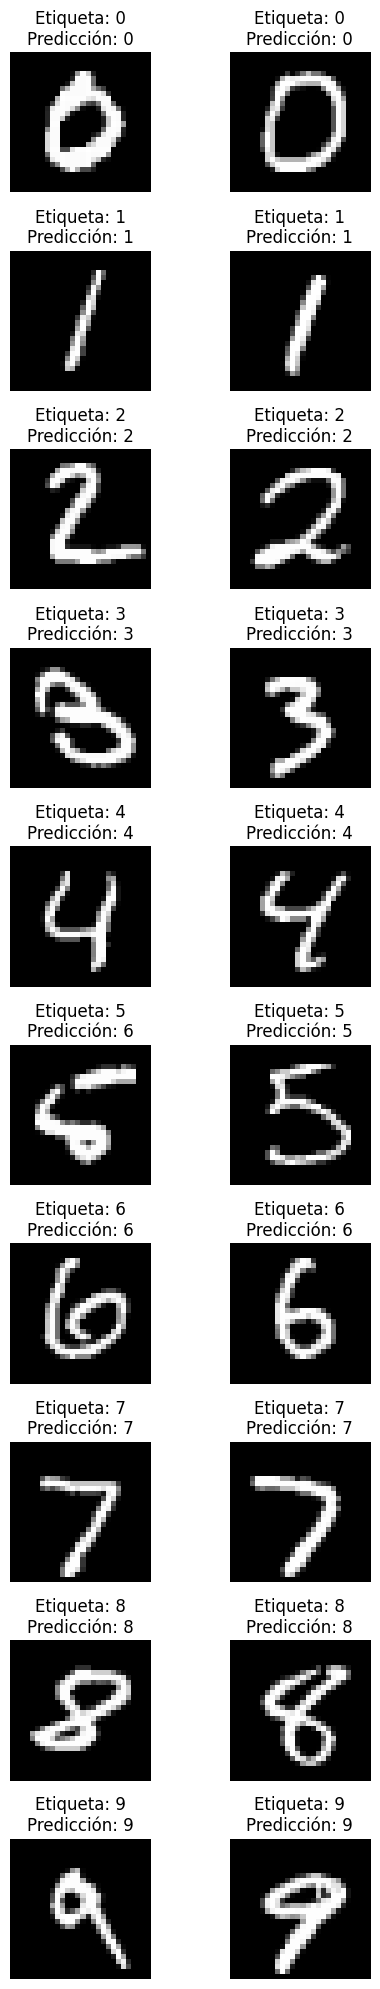

In [ ]:
# Evaluar el modelo con más métricas
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Predicciones
y_pred_probs = model.predict(x_test_flat)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Reporte de clasificación
print(classification_report(y_true, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:")
print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.show()

# Graficar 2 ejemplos de cada dígito (0-9)
fig, axes = plt.subplots(10, 2, figsize=(5, 20))
for digit in range(10):
    idxs = np.where(y_test == digit)[0][:2]
    for j, idx in enumerate(idxs):
        axes[digit, j].imshow(x_test[idx], cmap="gray")
        axes[digit, j].set_title(f"Etiqueta: {digit}\nPredicción: {y_pred[idx]}")
        axes[digit, j].axis("off")
plt.tight_layout()
plt.show()

## Preguntas de Reflexión (3 puntos en total)

### 1. ¿Qué ventaja observas al usar codificación one-hot para las etiquetas? (0.5 punto)

Dado que en este caso se tienen digitos de clasificación entre [0,9] , si bien uno podría interpretar orden éstas realmente no lo tienen. Por lo que one-hot encoding permite que sean representados de forma independiente y sin que se interpreten relaciones entre ellos. Por último es necesario usarlo para aplicar categorical_crossentropy algo que se pidió

### 2. ¿Qué ocurre si aumentas o disminuyes el número de neuronas ocultas? (0.5 punto)

Al aumentar las neuronas el modelo puede mejorar para aprender patrones más complejos pero a su vez se tiene el problema de tener overfitting y además el tiempo de entrenamiento sera mayor.
Al contrario si se disminuye será más rápido pero puede no captar todo lo escencial del dataset dando peores resultados.

### 3. ¿Qué alternativa propondrías al optimizador `adam` y por qué? (0.5 punto)

Una alternativa al optimizador `adam` es `SGD`. Aunque `adam` es el estándar por su rapidez y buen desempeño en la mayoría de los casos, `SGD` puede ser útil cuando se busca mayor control sobre el proceso de optimización, o cuando se quiere experimentar con técnicas clásicas para comparar resultados.

### 4. ¿Cómo cambia el desempeño si entrenas más épocas? ¿Cuál es el riesgo? (0.5 punto)

En  caso de entrena el modelo con más épocas, este permite que se ajusten mejor los pesos en cada época, de igual forma que en agregar más neuronas, muchas más épocas tiene el riesgo de overfitting.

### 5. ¿Por qué es importante dividir en conjuntos de entrenamiento y prueba? (1 punto)

Es importante para poder entrenar el modelo con datos y luego evaluarlo con datos que esté no ha visto en su entrenamiento para saber si el modelo generaliza bien en datos nuevos. Es decir si aprendió los patrones para detectar o memorizó los ejemplos.